In [1]:
# FarmTech Solutions — Fase 3
# Opcional 2: Machine Learning no Agronegócio
#
# Grupo:
# Ana Flora Lauris          | RM572202
# Clarice Oliveira Barreto  | RM571269
# Lucas Henrique A. G. de Mello | RM569583
# Kevin de Freitas Minervino | RM570667
# Renan Chaves Bezerra      | RM573532

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from google.colab import files

# Upload do arquivo
uploaded = files.upload()

# Funções de conversão
def converter_numerico(val, digitos_inteiros=2):
    s = str(val).replace('.', '').strip()
    n = float(s)
    if n == 0: return 0.0
    digits = int(math.log10(abs(n))) + 1
    divisor = 10 ** (digits - digitos_inteiros)
    return n / divisor

def converter_ph(val):
    s = str(val).replace('.', '').strip()
    n = float(s)
    if n == 0: return 0.0
    digits = int(math.log10(abs(n))) + 1
    divisor = 10 ** (digits - 1)
    return n / divisor

# Carregando e corrigindo o dataset
nome_arquivo = list(uploaded.keys())[0]
df = pd.read_csv(nome_arquivo, sep=';')

df['temperature'] = df['temperature'].apply(lambda x: converter_numerico(x, 2))
df['humidity']    = df['humidity'].apply(lambda x: converter_numerico(x, 2))
df['ph']          = df['ph'].apply(converter_ph)
df['rainfall']    = df['rainfall'].apply(lambda x: converter_numerico(x, 3))

print("Shape:", df.shape)
print("\nTipos das colunas:")
print(df.dtypes)
print("\nPrimeiras linhas:")
df.head()


Saving Atividade_Cap10_produtos_agricolas (1).csv to Atividade_Cap10_produtos_agricolas (1).csv
Shape: (2200, 8)

Tipos das colunas:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Primeiras linhas:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


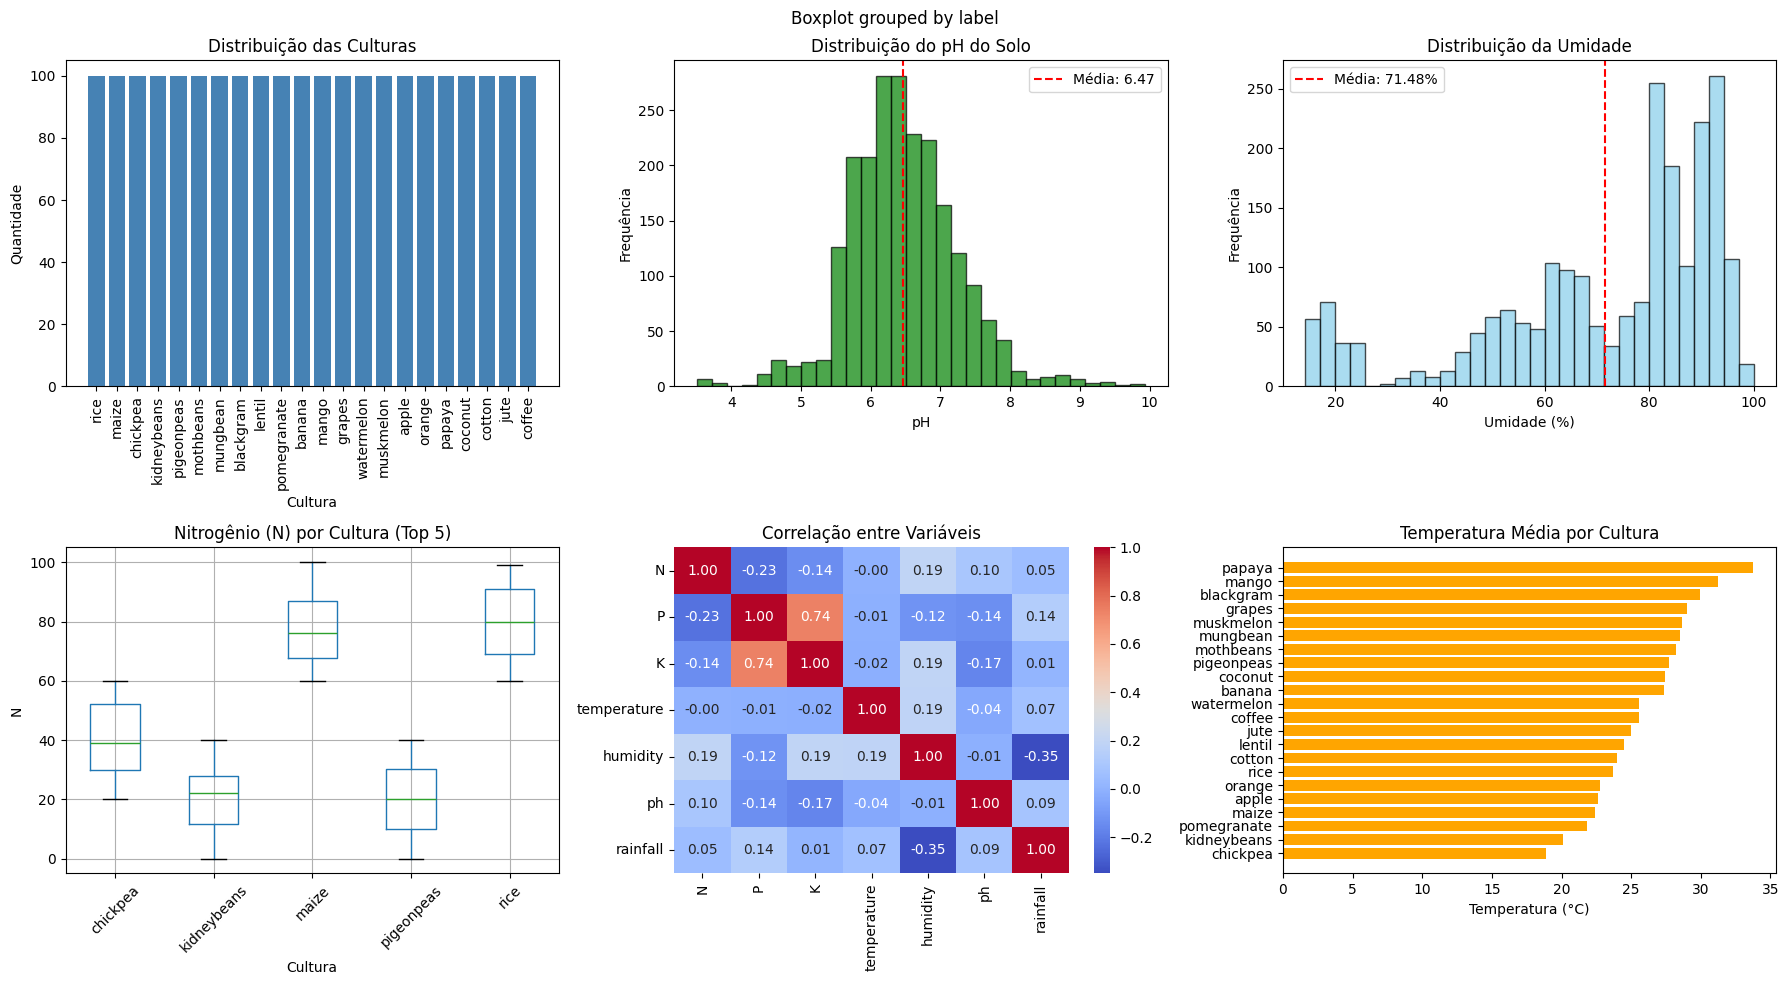

Gráficos gerados!


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('FarmTech Solutions — Análise Exploratória', fontsize=16, fontweight='bold')

# Gráfico 1: Distribuição de culturas
culturas_count = df['label'].value_counts()
axes[0,0].bar(culturas_count.index, culturas_count.values, color='steelblue')
axes[0,0].set_title('Distribuição das Culturas')
axes[0,0].set_xlabel('Cultura')
axes[0,0].set_ylabel('Quantidade')
axes[0,0].tick_params(axis='x', rotation=90)

# Gráfico 2: Distribuição do pH
axes[0,1].hist(df['ph'], bins=30, color='green', edgecolor='black', alpha=0.7)
axes[0,1].set_title('Distribuição do pH do Solo')
axes[0,1].set_xlabel('pH')
axes[0,1].set_ylabel('Frequência')
axes[0,1].axvline(df['ph'].mean(), color='red', linestyle='--', label=f'Média: {df["ph"].mean():.2f}')
axes[0,1].legend()

# Gráfico 3: Distribuição de umidade
axes[0,2].hist(df['humidity'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,2].set_title('Distribuição da Umidade')
axes[0,2].set_xlabel('Umidade (%)')
axes[0,2].set_ylabel('Frequência')
axes[0,2].axvline(df['humidity'].mean(), color='red', linestyle='--', label=f'Média: {df["humidity"].mean():.2f}%')
axes[0,2].legend()

# Gráfico 4: Boxplot NPK por cultura (top 5)
top5 = df['label'].value_counts().head(5).index
df_top5 = df[df['label'].isin(top5)]
df_top5.boxplot(column='N', by='label', ax=axes[1,0])
axes[1,0].set_title('Nitrogênio (N) por Cultura (Top 5)')
axes[1,0].set_xlabel('Cultura')
axes[1,0].set_ylabel('N')
plt.sca(axes[1,0])
plt.xticks(rotation=45)

# Gráfico 5: Mapa de correlação
corr = df[['N','P','K','temperature','humidity','ph','rainfall']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlação entre Variáveis')

# Gráfico 6: Temperatura média por cultura
temp_media = df.groupby('label')['temperature'].mean().sort_values()
axes[1,2].barh(temp_media.index, temp_media.values, color='orange')
axes[1,2].set_title('Temperatura Média por Cultura')
axes[1,2].set_xlabel('Temperatura (°C)')

plt.tight_layout()
plt.savefig('grafico_exploratoria.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráficos gerados!")

PERFIL IDEAL DE SOLO E CLIMA POR CULTURA

🌾 RICE
   N           : 79.89  (±11.92)
   P           : 47.58  (±7.90)
   K           : 39.87  (±2.95)
   temperature : 23.69  (±2.03)
   humidity    : 82.27  (±1.42)
   ph          : 6.43  (±0.77)
   rainfall    : 236.18  (±34.29)

🌾 MAIZE
   N           : 77.76  (±11.95)
   P           : 48.44  (±8.01)
   K           : 19.79  (±2.94)
   temperature : 22.39  (±2.68)
   humidity    : 65.09  (±5.45)
   ph          : 6.25  (±0.41)
   rainfall    : 610.30  (±308.72)

🌾 COFFEE
   N           : 101.20  (±12.35)
   P           : 28.74  (±7.28)
   K           : 29.94  (±3.25)
   temperature : 25.54  (±1.50)
   humidity    : 58.87  (±5.84)
   ph          : 6.79  (±0.42)
   rainfall    : 158.07  (±25.70)


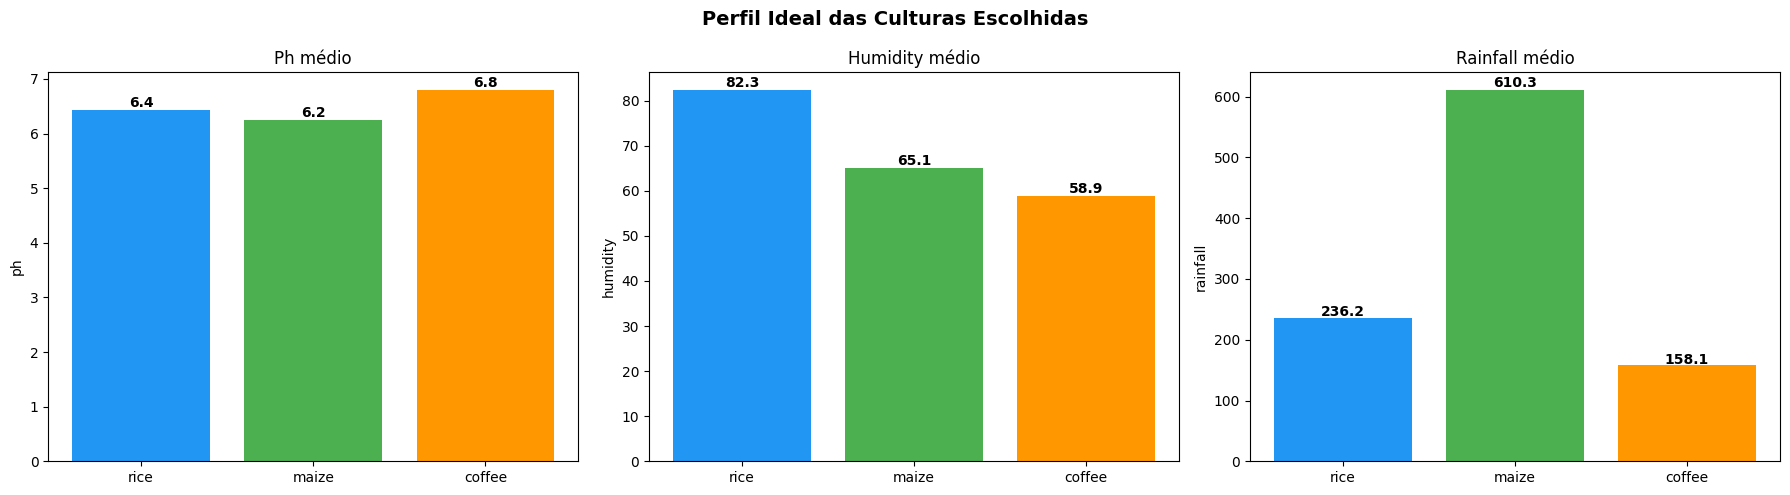

In [3]:
# Culturas escolhidas: rice, maize, coffee
culturas_escolhidas = ['rice', 'maize', 'coffee']

print("=" * 60)
print("PERFIL IDEAL DE SOLO E CLIMA POR CULTURA")
print("=" * 60)

variaveis = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

perfis = {}
for cultura in culturas_escolhidas:
    df_cultura = df[df['label'] == cultura]
    perfis[cultura] = df_cultura[variaveis].mean()
    print(f"\n🌾 {cultura.upper()}")
    for var in variaveis:
        print(f"   {var:12s}: {df_cultura[var].mean():.2f}  (±{df_cultura[var].std():.2f})")

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Perfil Ideal das Culturas Escolhidas', fontsize=14, fontweight='bold')

cores = ['#2196F3', '#4CAF50', '#FF9800']
for i, var in enumerate(['ph', 'humidity', 'rainfall']):
    valores = [perfis[c][var] for c in culturas_escolhidas]
    axes[i].bar(culturas_escolhidas, valores, color=cores)
    axes[i].set_title(f'{var.capitalize()} médio')
    axes[i].set_ylabel(var)
    for j, v in enumerate(valores):
        axes[i].text(j, v + v*0.01, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_perfil_culturas.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Preparação
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"Classes: {len(le.classes_)} culturas")

# 5 Modelos
modelos = {
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':         GaussianNB()
}

resultados = {}
print("\nTreinando modelos...")
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados[nome] = acc
    print(f"  {nome:25s}: {acc*100:.2f}%")

Treino: 1760 amostras
Teste:  440 amostras
Classes: 22 culturas

Treinando modelos...
  Decision Tree            : 97.95%
  Random Forest            : 99.32%
  Gradient Boosting        : 97.95%
  KNN                      : 95.00%
  Naive Bayes              : 99.09%


/tmp/ipykernel_8938/77518524.py:35: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('grafico_modelos.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


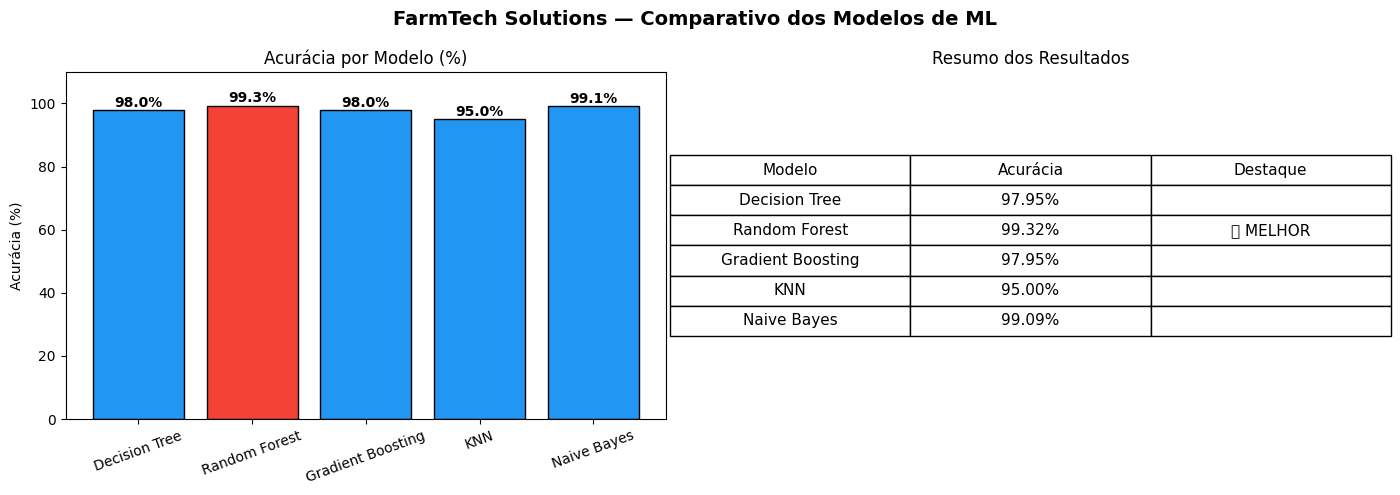


MELHOR MODELO: Random Forest (99.32%)
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.0

In [5]:
# Gráfico comparativo dos modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FarmTech Solutions — Comparativo dos Modelos de ML', fontsize=14, fontweight='bold')

nomes = list(resultados.keys())
acuracias = [v * 100 for v in resultados.values()]
cores_barras = ['#f44336' if a == max(acuracias) else '#2196F3' for a in acuracias]

# Barras de acurácia
bars = axes[0].bar(nomes, acuracias, color=cores_barras, edgecolor='black')
axes[0].set_title('Acurácia por Modelo (%)')
axes[0].set_ylabel('Acurácia (%)')
axes[0].set_ylim(0, 110)
axes[0].tick_params(axis='x', rotation=20)
for bar, acc in zip(bars, acuracias):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{acc:.1f}%', ha='center', fontweight='bold')

# Tabela resumo
tabela_dados = [[nome, f'{acc:.2f}%', '✅ MELHOR' if acc == max(acuracias) else '']
                for nome, acc in zip(nomes, acuracias)]
axes[1].axis('off')
tabela = axes[1].table(
    cellText=tabela_dados,
    colLabels=['Modelo', 'Acurácia', 'Destaque'],
    cellLoc='center',
    loc='center'
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1.2, 2)
axes[1].set_title('Resumo dos Resultados')

plt.tight_layout()
plt.savefig('grafico_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

# Melhor modelo — relatório detalhado
melhor_nome = max(resultados, key=resultados.get)
melhor_modelo = modelos[melhor_nome]
y_pred_melhor = melhor_modelo.predict(X_test)

print(f"\n{'='*60}")
print(f"MELHOR MODELO: {melhor_nome} ({resultados[melhor_nome]*100:.2f}%)")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_melhor, target_names=le.classes_))